# **SETUP DATASET & IMPORT LIBRARY**

In [1]:

!wget https://physionet.org/static/published-projects/hillel-yaffe-glaucoma-dataset/hillel-yaffe-glaucoma-dataset-1.0.0.zip
!unzip hillel-yaffe-glaucoma-dataset-1.0.0.zip
!mv hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0 glaucoma_dataset
!ls glaucoma_dataset

--2026-06-14 09:39:25--  https://physionet.org/static/published-projects/hillel-yaffe-glaucoma-dataset/hillel-yaffe-glaucoma-dataset-1.0.0.zip
Resolving physionet.org (physionet.org)... 18.25.8.254
Connecting to physionet.org (physionet.org)|18.25.8.254|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://physionet.org/content/hillel-yaffe-glaucoma-dataset/get-zip/1.0.0/ [following]
--2026-06-14 09:39:26--  https://physionet.org/content/hillel-yaffe-glaucoma-dataset/get-zip/1.0.0/
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 124214721 (118M) [application/zip]
Saving to: ‘hillel-yaffe-glaucoma-dataset-1.0.0.zip’

hillel-yaffe-glauco 100%[===================>] 118.46M   313KB/s    in 6m 2s   

2026-06-14 09:45:29 (335 KB/s) - ‘hillel-yaffe-glaucoma-dataset-1.0.0.zip’ saved [124214721/124214721]

Archive:  hillel-yaffe-glaucoma-dataset-1.0.0.zip
  inflating: hillel-yaffe-glaucoma-data

In [2]:
# import library
import os
import random
import copy
from pathlib import Path
from collections import Counter
from typing import Optional
import time
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast  # mixed-precision training
import torchvision.transforms as transforms
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, roc_curve
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅  Using device: {DEVICE}")


✅  Using device: cuda


In [3]:
path = "./glaucoma_dataset"

print("Memeriksa Path:", path)
print("------------------------------------------")

if os.path.exists(path):
    for root, dirs, files in os.walk(path):
        level = root.replace(path, '').count(os.sep)
        if level > 4:
            continue

        indent = '  ' * level
        print(f'{indent}📁 {os.path.basename(root)}/')
        sample_files = files[:5]
        for f in sample_files:
            print(f'{indent}  📄 {f}')
else:
    print("Folder tidak ditemukan. Pastikan nama foldernya sudah sesuai.")

Memeriksa Path: ./glaucoma_dataset
------------------------------------------
📁 glaucoma_dataset/
  📄 SHA256SUMS.txt
  📄 Labels.csv
  📄 README.md
  📄 LICENSE.txt
  📁 Images/
    📄 179_2.jpg
    📄 107_0.jpg
    📄 170_5.jpg
    📄 226_0.jpg
    📄 37_0.jpg


In [4]:
# Cek jumlah images
image_dir = Path("./glaucoma_dataset/Images")

# Hitung semua file jpg
all_images = list(image_dir.glob("*.jpg"))
print(f"Total images: {len(all_images)}")

Total images: 747


# **DATA PIPELINE**

In [5]:
# =============================================================================
# 1. CONFIGURATION
# =============================================================================

class Config:
    """Central configuration — edit these paths to match your environment."""

    # ── Paths ─────────────────────────────────────────────────────────────────
    DATASET_ROOT  = Path("./glaucoma_dataset")          # root folder
    IMAGE_DIR     = DATASET_ROOT / "Images"             # JPG images
    LABELS_CSV    = DATASET_ROOT / "Labels.csv"         # metadata file

    # ── Split ratios (must sum to 1.0) ────────────────────────────────────────
    TRAIN_RATIO   = 0.70
    VAL_RATIO     = 0.15
    TEST_RATIO    = 0.15   # remainder goes to test

    # ── Image preprocessing ───────────────────────────────────────────────────
    IMAGE_SIZE    = 224    # standard for ImageNet-pretrained backbones
    BATCH_SIZE    = 32
    NUM_WORKERS   = 2

    # ── Quality score bands ───────────────────────────────────────────────────
    QUALITY_LOW   = (1, 3)
    QUALITY_MED   = (4, 7)
    QUALITY_HIGH  = (8, 10)

    # ── Class label mapping ───────────────────────────────────────────────────
    LABEL_MAP     = {"GON+": 1, "GON-": 0}  # positive class = 1

In [6]:
# =============================================================================
# 2. DATA LOADING & VALIDATION
# =============================================================================

def load_and_validate_labels(cfg: Config) -> pd.DataFrame:
    """
    Load Labels.csv, standardise column names, and validate that every
    listed image actually exists on disk.

    Returns
    -------
    pd.DataFrame
        Cleaned dataframe with columns:
        [image_name, patient_id, label, quality_score, label_enc, image_path]
    """
    df = pd.read_csv(cfg.LABELS_CSV)

    # ── Normalise column names (strip whitespace, lower-snake-case) ───────────
    df.columns = (
        df.columns.str.strip()
                  .str.lower()
                  .str.replace(" ", "_")
    )

    # Rename to standard internal names (adjust if your CSV differs)
    rename_map = {
        "image name": "image_name",
        "image_name": "image_name",
        "patient":    "patient_id",
        "label":      "label",
        "quality score": "quality_score",
        "quality_score": "quality_score",
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

    required_cols = {"image_name", "patient_id", "label", "quality_score"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Labels.csv is missing expected columns: {missing}")

    # ── Encode labels to integers ─────────────────────────────────────────────
    df["label_enc"] = df["label"].map(cfg.LABEL_MAP)
    assert df["label_enc"].notna().all(), "Unknown label values found — check LABEL_MAP."

    # ── Build full image paths & verify existence ─────────────────────────────
    df["image_path"] = df["image_name"].apply(
        lambda fn: str(cfg.IMAGE_DIR / fn)
    )
    missing_files = df[~df["image_path"].apply(os.path.exists)]
    if not missing_files.empty:
        print(f"⚠  WARNING: {len(missing_files)} images listed in CSV not found on disk.")
        print(missing_files["image_name"].tolist()[:10])

    # ── Drop rows without a valid image ──────────────────────────────────────
    df = df[df["image_path"].apply(os.path.exists)].reset_index(drop=True)

    print(f"✅  Loaded {len(df)} valid image records from {df['patient_id'].nunique()} patients.")
    return df

In [7]:
# =============================================================================
# 3. PATIENT-LEVEL TRAIN / VAL / TEST SPLIT
# =============================================================================

def patient_level_split(
    df: pd.DataFrame,
    cfg: Config,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Split dataset at the PATIENT level to prevent data leakage.

    Strategy
    --------
    1. Collect the set of unique patient IDs.
    2. Shuffle them with a fixed seed.
    3. Slice into train / val / test pools by the configured ratios.
    4. Map patient pools back to image rows.

    This guarantees that NO image from the same patient appears in two
    different splits — a hard requirement to avoid leakage penalties.

    Returns
    -------
    train_df, val_df, test_df : pd.DataFrame
    """
    all_patients = df["patient_id"].unique().tolist()
    random.shuffle(all_patients)

    n   = len(all_patients)
    n_train = int(np.floor(cfg.TRAIN_RATIO * n))
    n_val   = int(np.floor(cfg.VAL_RATIO   * n))
    # test gets the remainder (avoids rounding loss)

    train_patients = set(all_patients[:n_train])
    val_patients   = set(all_patients[n_train : n_train + n_val])
    test_patients  = set(all_patients[n_train + n_val :])

    train_df = df[df["patient_id"].isin(train_patients)].reset_index(drop=True)
    val_df   = df[df["patient_id"].isin(val_patients)  ].reset_index(drop=True)
    test_df  = df[df["patient_id"].isin(test_patients) ].reset_index(drop=True)

    return train_df, val_df, test_df


def verify_no_leakage(
    train_df: pd.DataFrame,
    val_df:   pd.DataFrame,
    test_df:  pd.DataFrame,
) -> None:
    """
    Assert zero patient overlap across all three splits.
    Prints a verification table and raises AssertionError if leakage is found.
    """
    train_pts = set(train_df["patient_id"])
    val_pts   = set(val_df  ["patient_id"])
    test_pts  = set(test_df ["patient_id"])

    tv = train_pts & val_pts
    tt = train_pts & test_pts
    vt = val_pts   & test_pts

    print("\n" + "═"*52)
    print("  DATA LEAKAGE VERIFICATION")
    print("═"*52)
    print(f"  Train  patients : {len(train_pts):>4}")
    print(f"  Val    patients : {len(val_pts):>4}")
    print(f"  Test   patients : {len(test_pts):>4}")
    print(f"  Train ∩ Val     : {len(tv):>4}  {'✅ CLEAN' if not tv else '❌ LEAKAGE!'}")
    print(f"  Train ∩ Test    : {len(tt):>4}  {'✅ CLEAN' if not tt else '❌ LEAKAGE!'}")
    print(f"  Val   ∩ Test    : {len(vt):>4}  {'✅ CLEAN' if not vt else '❌ LEAKAGE!'}")
    print("═"*52)

    assert not tv, f"DATA LEAKAGE: {len(tv)} patients shared between Train and Val!"
    assert not tt, f"DATA LEAKAGE: {len(tt)} patients shared between Train and Test!"
    assert not vt, f"DATA LEAKAGE: {len(vt)} patients shared between Val and Test!"
    print("  ✅  Zero leakage confirmed — patient-level split is clean.\n")

In [8]:
# =============================================================================
# 4. EXPLORATORY DATA ANALYSIS (EDA) FUNCTION
# =============================================================================

def eda_class_distribution(df: pd.DataFrame, title: str = "Full Dataset") -> None:
    """Bar chart + printed counts for GON+ / GON- class balance."""
    counts = df["label"].value_counts()
    total  = len(df)

    print(f"\n── Class Distribution ({title}) ──────────────────")
    for lbl, cnt in counts.items():
        print(f"  {lbl:6s}: {cnt:4d}  ({cnt/total*100:.1f}%)")
    print(f"  Total : {total}")

    fig, ax = plt.subplots(figsize=(5, 4))
    colors = ["#e05c5c", "#5c8ee0"]
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="white", width=0.5)
    ax.bar_label(bars, fmt="%d", padding=3, fontsize=11)
    ax.set_title(f"Class Distribution — {title}", fontsize=13, fontweight="bold")
    ax.set_ylabel("Image Count")
    ax.set_ylim(0, counts.max() * 1.2)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig(f"eda_class_dist_{title.replace(' ', '_')}.png", dpi=150)
    plt.show()


def eda_split_summary(
    train_df: pd.DataFrame,
    val_df:   pd.DataFrame,
    test_df:  pd.DataFrame,
) -> None:
    """Printed summary table with patient counts, image counts, and class ratios per split."""
    print("\n── Split Summary ─────────────────────────────────────────")
    header = f"{'Split':8} {'Patients':>9} {'Images':>8} {'GON+':>7} {'GON-':>7} {'Imbalance':>10}"
    print(header)
    print("-" * len(header))

    for name, subset in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
        n_pt   = subset["patient_id"].nunique()
        n_img  = len(subset)
        n_pos  = (subset["label_enc"] == 1).sum()
        n_neg  = (subset["label_enc"] == 0).sum()
        ratio  = n_pos / n_neg if n_neg > 0 else float("inf")
        print(f"{name:8} {n_pt:9d} {n_img:8d} {n_pos:7d} {n_neg:7d} {ratio:9.2f}x")
    print()


def eda_quality_distribution(df: pd.DataFrame) -> None:
    """Histogram of quality scores with vertical lines for band boundaries."""
    fig, ax = plt.subplots(figsize=(7, 4))

    ax.hist(df["quality_score"], bins=range(1, 12), color="#5ca8e0",
            edgecolor="white", rwidth=0.85, align="left")

    # Mark quality bands
    ax.axvline(3.5, color="#e07a5c", linestyle="--", linewidth=1.5, label="Low | Med boundary")
    ax.axvline(7.5, color="#5ce07a", linestyle="--", linewidth=1.5, label="Med | High boundary")

    ax.set_title("Quality Score Distribution", fontsize=13, fontweight="bold")
    ax.set_xlabel("Quality Score (1–10)")
    ax.set_ylabel("Image Count")
    ax.set_xticks(range(1, 11))
    ax.legend()
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig("eda_quality_dist.png", dpi=150)
    plt.show()

    # Print band counts
    low  = df[df["quality_score"].between(*Config.QUALITY_LOW)]
    med  = df[df["quality_score"].between(*Config.QUALITY_MED)]
    high = df[df["quality_score"].between(*Config.QUALITY_HIGH)]
    print(f"\n── Quality Bands ─────────────────────────────────────────")
    print(f"  Low  (1–3)  : {len(low):4d} images  ({len(low)/len(df)*100:.1f}%)")
    print(f"  Med  (4–7)  : {len(med):4d} images  ({len(med)/len(df)*100:.1f}%)")
    print(f"  High (8–10) : {len(high):4d} images  ({len(high)/len(df)*100:.1f}%)")


def eda_sample_images(df: pd.DataFrame, n_per_band: int = 3) -> None:
    """
    Display sample fundus images for each quality band (low / medium / high).
    Images are NOT available in this environment, so this function renders
    placeholder tiles — replace with Image.open() when running locally.
    """
    cfg = Config()
    bands = {
        f"Low Quality (1–3)":   df[df["quality_score"].between(*cfg.QUALITY_LOW)],
        f"Medium Quality (4–7)": df[df["quality_score"].between(*cfg.QUALITY_MED)],
        f"High Quality (8–10)":  df[df["quality_score"].between(*cfg.QUALITY_HIGH)],
    }

    fig = plt.figure(figsize=(4 * n_per_band, 4 * len(bands)))
    gs  = gridspec.GridSpec(len(bands), n_per_band, figure=fig,
                             hspace=0.4, wspace=0.2)

    for row_idx, (band_name, band_df) in enumerate(bands.items()):
        samples = band_df.sample(min(n_per_band, len(band_df)), random_state=SEED)

        for col_idx, (_, row) in enumerate(samples.iterrows()):
            ax = fig.add_subplot(gs[row_idx, col_idx])
            try:
                img = Image.open(row["image_path"]).convert("RGB")
                ax.imshow(img)
            except Exception:
                ax.text(0.5, 0.5, "Image\nnot found",
                        ha="center", va="center", transform=ax.transAxes,
                        fontsize=9, color="grey")
                ax.set_facecolor("#1a1a2e")

            lbl   = row["label"]
            qscore = row["quality_score"]
            ax.set_title(f"{lbl} | Q={qscore}", fontsize=9)
            ax.axis("off")

        # Row label on the left
        fig.text(0.01, 1 - (row_idx + 0.5) / len(bands), band_name,
                 va="center", fontsize=11, fontweight="bold", rotation=90)

    fig.suptitle("Sample Fundus Images by Quality Band", fontsize=14, fontweight="bold", y=1.01)
    plt.savefig("eda_sample_images.png", dpi=150, bbox_inches="tight")
    plt.show()

In [9]:
# =============================================================================
# 5. PYTORCH DATASET
# =============================================================================

def get_transforms(split: str, image_size: int) -> transforms.Compose:
    """
    Return appropriate torchvision transforms for each split.

    Train  → aggressive augmentation to combat overfitting + class imbalance
    Val / Test → deterministic resize + normalise only (no augmentation)

    Normalisation values use ImageNet mean/std — appropriate when using
    pretrained backbones; also a reasonable baseline for custom CNNs.
    """
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    if split == "train":
        return transforms.Compose([
            transforms.Resize((image_size + 32, image_size + 32)),
            transforms.RandomCrop(image_size),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.ColorJitter(
                brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05
            ),
            transforms.RandomRotation(degrees=15),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
    else:  # val / test — deterministic
        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])


class HYGDDataset(Dataset):
    """
    PyTorch Dataset for the Hillel Yaffe Glaucoma Dataset.

    Parameters
    ----------
    dataframe     : pd.DataFrame from patient_level_split()
    transform     : torchvision.transforms.Compose
    return_quality: if True, __getitem__ also returns the quality score
                    (useful for quality-aware loss weighting experiments)
    """

    def __init__(
        self,
        dataframe: pd.DataFrame,
        transform: transforms.Compose,
        return_quality: bool = False,
    ):
        self.df             = dataframe.reset_index(drop=True)
        self.transform      = transform
        self.return_quality = return_quality

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row   = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        image = self.transform(image)
        label = torch.tensor(row["label_enc"], dtype=torch.long)

        if self.return_quality:
            quality = torch.tensor(row["quality_score"], dtype=torch.float32)
            return image, label, quality
        return image, label

In [10]:
# =============================================================================
# 6. CLASS IMBALANCE — WeightedRandomSampler
# =============================================================================

def build_weighted_sampler(train_df: pd.DataFrame) -> WeightedRandomSampler:
    """
    Build a WeightedRandomSampler that up-samples the minority class (GON-)
    so each training batch sees an approximately balanced class ratio.

    Why this approach?
    ──────────────────
    GON+ : GON- ≈ 2.75 : 1  →  naïve training biases toward GON+.
    WeightedRandomSampler assigns each sample a weight inversely proportional
    to its class frequency, then samples *with replacement* to form batches.
    This is preferred over simple oversampling because it interacts cleanly
    with data augmentation (each sampled image still gets a random transform).
    """
    labels       = train_df["label_enc"].values
    class_counts = Counter(labels)
    total        = len(labels)

    # Weight per class = total / count  (larger weight → more often sampled)
    class_weights = {cls: total / cnt for cls, cnt in class_counts.items()}
    sample_weights = torch.tensor(
        [class_weights[lbl] for lbl in labels], dtype=torch.float64
    )

    sampler = WeightedRandomSampler(
        weights     = sample_weights,
        num_samples = len(sample_weights),
        replacement = True,
    )

    print(f"── WeightedRandomSampler ─────────────────────────────────")
    for cls, cnt in sorted(class_counts.items()):
        lbl_name = {0: "GON-", 1: "GON+"}[cls]
        print(f"  Class {lbl_name} (id={cls}): {cnt:4d} images  weight={class_weights[cls]:.4f}")
    print()
    return sampler


In [11]:
# =============================================================================
# 7. DATALOADER FACTORY
# =============================================================================

def build_dataloaders(
    train_df : pd.DataFrame,
    val_df   : pd.DataFrame,
    test_df  : pd.DataFrame,
    cfg      : Config,
    return_quality: bool = False,
) -> dict[str, DataLoader]:
    """
    Create train / val / test DataLoaders.

    Training loader uses WeightedRandomSampler (mutually exclusive with
    shuffle=True — PyTorch raises an error if both are set).

    Returns
    -------
    dict with keys "train", "val", "test"
    """
    tfm = {
        "train": get_transforms("train", cfg.IMAGE_SIZE),
        "val"  : get_transforms("val",   cfg.IMAGE_SIZE),
        "test" : get_transforms("test",  cfg.IMAGE_SIZE),
    }

    datasets = {
        "train": HYGDDataset(train_df, tfm["train"], return_quality),
        "val"  : HYGDDataset(val_df,   tfm["val"],   return_quality),
        "test" : HYGDDataset(test_df,  tfm["test"],  return_quality),
    }

    sampler = build_weighted_sampler(train_df)

    loaders = {
        "train": DataLoader(
            datasets["train"],
            batch_size  = cfg.BATCH_SIZE,
            sampler     = sampler,        # replaces shuffle=True
            num_workers = cfg.NUM_WORKERS,
            pin_memory  = True,
            drop_last   = True,
        ),
        "val": DataLoader(
            datasets["val"],
            batch_size  = cfg.BATCH_SIZE,
            shuffle     = False,
            num_workers = cfg.NUM_WORKERS,
            pin_memory  = True,
        ),
        "test": DataLoader(
            datasets["test"],
            batch_size  = cfg.BATCH_SIZE,
            shuffle     = False,
            num_workers = cfg.NUM_WORKERS,
            pin_memory  = True,
        ),
    }

    # ── Sanity print ─────────────────────────────────────────────────────────
    print("── DataLoader Summary ────────────────────────────────────")
    for name, loader in loaders.items():
        n_batches = len(loader)
        n_samples = len(loader.dataset)
        print(f"  {name:6s}: {n_samples:4d} images  →  {n_batches} batches  (bs={cfg.BATCH_SIZE})")
    print()

    return loaders

In [12]:
# =============================================================================
# 8. COMPUTE CLASS WEIGHTS FOR LOSS FUNCTION  (alternative / complementary)
# =============================================================================

def compute_class_weights_for_loss(train_df: pd.DataFrame) -> torch.Tensor:
    """
    Compute class weights to pass to nn.CrossEntropyLoss(weight=...).

    This is an ALTERNATIVE (or complement) to WeightedRandomSampler —
    the loss penalises misclassification of the minority class more heavily.

    Usage in training loop:
        criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    """
    labels       = train_df["label_enc"].values
    class_counts = np.bincount(labels)                         # [n_neg, n_pos]
    weights      = 1.0 / class_counts                         # inverse frequency
    weights      = weights / weights.sum() * len(class_counts) # normalise

    tensor_weights = torch.tensor(weights, dtype=torch.float32)
    print(f"── Loss Class Weights ────────────────────────────────────")
    print(f"  GON- (0): {tensor_weights[0]:.4f}")
    print(f"  GON+ (1): {tensor_weights[1]:.4f}")
    print(f"  (Use: nn.CrossEntropyLoss(weight=class_weights.to(device)))\n")
    return tensor_weights

# **MODEL ARCHITECTURE**

In [13]:
# =============================================================================
#  1 — BUILDING BLOCKS
# =============================================================================

class ConvBlock(nn.Module):
    """
    Reusable Conv → BN → Activation block.

    Design choices:
    ───────────────
    • kernel_size=3  : The 3×3 kernel is the standard in modern CNNs (VGG,
                       ResNet). Two stacked 3×3 layers cover the same receptive
                       field as one 5×5 but with fewer parameters and an extra
                       non-linearity between them.
    • Batch Normalisation BEFORE activation : reduces internal covariate shift,
      allows higher learning rates, and acts as a mild regulariser. Placing it
      before ReLU is slightly more common in medical imaging literature.
    • LeakyReLU(0.01) : avoids the "dying ReLU" problem where neurons with
      large negative pre-activations become permanently inactive — important
      when the dataset is small and gradients can be sparse.
    • padding=1 with stride=1 : preserves spatial size so pooling controls
      downsampling explicitly (easier to reason about).
    """

    def __init__(
        self,
        in_channels:  int,
        out_channels: int,
        kernel_size:  int = 3,
        stride:       int = 1,
        padding:      int = 1,
    ):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels,
                      kernel_size=kernel_size,
                      stride=stride,
                      padding=padding,
                      bias=False),          # bias=False because BN absorbs it
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(negative_slope=0.01, inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation (SE) channel attention block.

    Motivation for inclusion:
    ─────────────────────────
    Fundus images have highly structured anatomy (optic disc, macula, vessels).
    SE allows the network to re-weight WHICH feature maps (channels) are most
    diagnostic for each image, rather than treating all channels equally.
    This is a lightweight attention mechanism (~2× fc layers) that consistently
    improves medical image CNNs at minimal parameter cost.

    reduction_ratio=16 is the standard from Hu et al. (2018) — balances
    capacity gain vs. parameter overhead.
    """

    def __init__(self, channels: int, reduction_ratio: int = 16):
        super().__init__()
        squeezed = max(channels // reduction_ratio, 4)   # floor at 4
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),                      # global average pool
            nn.Flatten(),
            nn.Linear(channels, squeezed, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(squeezed, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        scale = self.se(x).unsqueeze(-1).unsqueeze(-1)   # (B, C, 1, 1)
        return x * scale                                  # channel-wise scaling


In [14]:
# =============================================================================
#  2 — MODEL 1: BASELINE CUSTOM CNN
# =============================================================================

class GlaucomaBaseCNN(nn.Module):
    """
    Custom CNN Baseline — trained WITHOUT quality scores.

    Architecture at a glance (input: 3 × 224 × 224)
    ─────────────────────────────────────────────────
    Stage 1 : [Conv3×3 → BN → LReLU] × 2  |  32 ch  |  224 → 112  (MaxPool)
    Stage 2 : [Conv3×3 → BN → LReLU] × 2  |  64 ch  |  112 →  56  (MaxPool)
    Stage 3 : [Conv3×3 → BN → LReLU] × 2  | 128 ch  |   56 →  28  (MaxPool)
    Stage 4 : [Conv3×3 → BN → LReLU] × 2  | 256 ch  |   28 →  14  (MaxPool)
              + SE channel attention
    AdaptiveAvgPool → 256 × 4 × 4 = 4096 features
    FC Head: 4096 → 512 → 128 → 2  (with Dropout)

    Channel progression (32 → 64 → 128 → 256):
      Doubling channels at each stage is the standard CNN design pattern —
      deeper features are more abstract and need higher representational
      capacity, compensated by halving spatial resolution at each stage.

    Dropout rates:
      0.4 in first FC layer : aggressive — first FC is the densest layer and
                               most prone to memorising training patterns.
      0.3 in second FC layer: moderate — the representation is already
                               compressed; too much dropout here loses signal.
    """

    def __init__(self, num_classes: int = 2, dropout_rate: float = 0.4):
        super().__init__()

        # ── Convolutional Feature Extractor ──────────────────────────────────
        self.features = nn.Sequential(
            # Stage 1 — low-level features (edges, colour gradients)
            ConvBlock(3,   32),
            ConvBlock(32,  32),
            nn.MaxPool2d(kernel_size=2, stride=2),   # 224 → 112
            nn.Dropout2d(0.1),                        # spatial dropout (mild)

            # Stage 2 — mid-level features (textures, vessel patterns)
            ConvBlock(32,  64),
            ConvBlock(64,  64),
            nn.MaxPool2d(kernel_size=2, stride=2),   # 112 → 56
            nn.Dropout2d(0.1),

            # Stage 3 — semantic features (optic disc shape, cup-to-disc)
            ConvBlock(64,  128),
            ConvBlock(128, 128),
            nn.MaxPool2d(kernel_size=2, stride=2),   # 56 → 28
            nn.Dropout2d(0.15),

            # Stage 4 — high-level discriminative features
            ConvBlock(128, 256),
            ConvBlock(256, 256),
            SEBlock(256),                             # channel attention here
            nn.MaxPool2d(kernel_size=2, stride=2),   # 28 → 14
        )

        # AdaptiveAvgPool: collapses spatial dims to a fixed 4×4 regardless
        # of input size — makes the model robust to small size variations
        # and avoids hard-coding the FC input size.
        self.pool = nn.AdaptiveAvgPool2d((4, 4))     # 14 → 4×4

        # ── Classification Head ───────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Dropout(dropout_rate),                 # 0.4

            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Dropout(dropout_rate - 0.1),           # 0.3

            nn.Linear(128, num_classes),              # raw logits (no softmax)
        )

        # ── Weight Initialisation ─────────────────────────────────────────────
        self._init_weights()

    def _init_weights(self) -> None:
        """
        Kaiming (He) initialisation for Conv layers — designed for ReLU
        activations. Keeps gradient variance stable across many layers,
        critical for medical CNNs trained from scratch on small datasets.
        """
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out",
                                        nonlinearity="leaky_relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="leaky_relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

    def get_feature_maps(self, x: torch.Tensor) -> torch.Tensor:
        """Returns feature maps before classifier — used for Grad-CAM."""
        x = self.features(x)
        return self.pool(x)

In [15]:
# =============================================================================
#  3 — MODEL 2: QUALITY-AWARE CNN (STRATEGY C)
# =============================================================================

class QualityEncoder(nn.Module):
    """
    Encode the scalar quality score (1–10) into a learned embedding vector.

    Why not pass the raw scalar directly?
    ──────────────────────────────────────
    A raw scalar [0.1 … 1.0] has very low information density compared to the
    visual feature vector (128-d). The encoder projects it into a richer space
    where the network can learn non-linear quality-to-confidence relationships
    (e.g., "quality 7 → still mostly reliable", "quality 2 → near-random").

    The quality score is first NORMALISED to [0, 1] by dividing by 10, then
    expanded to a 16-d embedding — small enough not to dominate the visual
    features, large enough to be expressive.
    """

    def __init__(self, embed_dim: int = 16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, embed_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, q: torch.Tensor) -> torch.Tensor:
        # q: (B,) raw scores 1–10  →  normalise  →  (B, 1)
        q_norm = (q / 10.0).unsqueeze(1)
        return self.encoder(q_norm)   # (B, embed_dim)


class GlaucomaQualityCNN(nn.Module):
    """
    Quality-Aware CNN — Strategy C: Auxiliary Quality Input.

    Architecture modification vs Baseline:
    ───────────────────────────────────────
    The convolutional backbone is IDENTICAL to GlaucomaBaseCNN (same stages,
    same channel progression, same SE block). Only the FC head changes:

    Baseline head  :  visual_feat(256×4×4=4096) → 512 → 128 → 2
    Quality head   :  visual_feat(4096) + quality_embed(16) → 528
                      → FC(528 → 512) → FC(512 → 128) → FC(128 → 2)

    The quality embedding is CONCATENATED with the visual feature vector
    before the first FC layer. This fusion point is chosen deliberately:
    • Too early (e.g., at Stage 1): quality modulates low-level edge detectors
      — not meaningful. Image noise does affect edges, but the relationship is
      complex enough that we want the CNN to learn visual quality features
      itself.
    • At the FC head: quality directly gates the DECISION, not the feature
      extraction. This is the most interpretable and clinically sensible place.

    During training on quality-aware batches, the model learns:
      "For low-quality images, be more conservative (push logits toward
       the uncertain region); for high-quality images, commit more strongly."
    """

    def __init__(self, num_classes: int = 2, dropout_rate: float = 0.4,
                 quality_embed_dim: int = 16):
        super().__init__()

        # ── Shared backbone (identical to baseline) ───────────────────────────
        self.features = nn.Sequential(
            ConvBlock(3,   32), ConvBlock(32,  32),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.1),

            ConvBlock(32,  64), ConvBlock(64,  64),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.1),

            ConvBlock(64,  128), ConvBlock(128, 128),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.15),

            ConvBlock(128, 256), ConvBlock(256, 256),
            SEBlock(256),
            nn.MaxPool2d(2, 2),
        )
        self.pool = nn.AdaptiveAvgPool2d((4, 4))

        # ── Quality encoder ───────────────────────────────────────────────────
        self.quality_embed_dim = quality_embed_dim
        self.quality_encoder   = QualityEncoder(embed_dim=quality_embed_dim)

        # ── Quality-aware classification head ─────────────────────────────────
        visual_dim = 256 * 4 * 4                          # 4096
        fused_dim  = visual_dim + quality_embed_dim       # 4096 + 16 = 4112

        self.classifier = nn.Sequential(
            nn.Flatten(),
            # After flatten the quality vector is concatenated in forward()
        )

        # FC layers defined separately to allow the cat() in forward
        self.fc1 = nn.Sequential(
            nn.Linear(fused_dim, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Dropout(dropout_rate),
        )
        self.fc2 = nn.Sequential(
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Dropout(dropout_rate - 0.1),
        )
        self.fc_out = nn.Linear(128, num_classes)

        self._init_weights()

    def _init_weights(self) -> None:
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out",
                                        nonlinearity="leaky_relu")
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="leaky_relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor, quality: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        x       : (B, 3, 224, 224) — image tensor
        quality : (B,)              — quality scores in [1, 10]
        """
        # Visual pathway
        vis = self.pool(self.features(x))    # (B, 256, 4, 4)
        vis = vis.flatten(1)                 # (B, 4096)

        # Quality pathway
        q_emb = self.quality_encoder(quality.float())   # (B, 16)

        # Late fusion: concatenate along feature dimension
        fused = torch.cat([vis, q_emb], dim=1)          # (B, 4112)

        # Classification head
        out = self.fc1(fused)
        out = self.fc2(out)
        return self.fc_out(out)

    def get_feature_maps(self, x: torch.Tensor) -> torch.Tensor:
        """Feature maps before classifier — for Grad-CAM."""
        return self.pool(self.features(x))

In [16]:
# =============================================================================
#  4 — MODEL SUMMARY UTILITY
# =============================================================================

def count_parameters(model: nn.Module) -> int:
    """Count trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def print_model_summary(model: nn.Module, name: str) -> None:
    total  = count_parameters(model)
    print(f"\n{'═'*55}")
    print(f"  Model : {name}")
    print(f"  Trainable parameters : {total:,}")
    print(f"  Size (FP32)          : {total * 4 / 1024**2:.2f} MB")
    print(f"{'═'*55}")

✅  Loaded 747 valid image records from 288 patients.

════════════════════════════════════════════════════
  DATA LEAKAGE VERIFICATION
════════════════════════════════════════════════════
  Train  patients :  201
  Val    patients :   43
  Test   patients :   44
  Train ∩ Val     :    0  ✅ CLEAN
  Train ∩ Test    :    0  ✅ CLEAN
  Val   ∩ Test    :    0  ✅ CLEAN
════════════════════════════════════════════════════
  ✅  Zero leakage confirmed — patient-level split is clean.

── Loss Class Weights ────────────────────────────────────
  GON- (0): 1.4425
  GON+ (1): 0.5575
  (Use: nn.CrossEntropyLoss(weight=class_weights.to(device)))

── WeightedRandomSampler ─────────────────────────────────
  Class GON- (id=0):  143 images  weight=3.5874
  Class GON+ (id=1):  370 images  weight=1.3865

── DataLoader Summary ────────────────────────────────────
  train :  513 images  →  16 batches  (bs=32)
  val   :  118 images  →  4 batches  (bs=32)
  test  :  116 images  →  4 batches  (bs=32)

── Weight

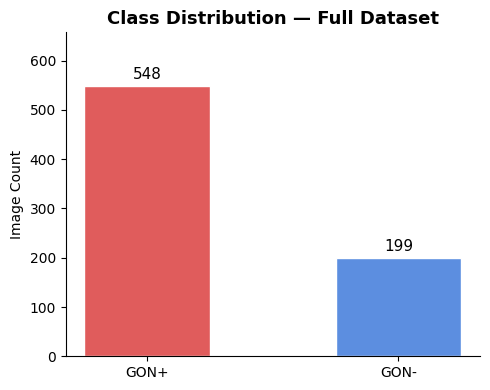

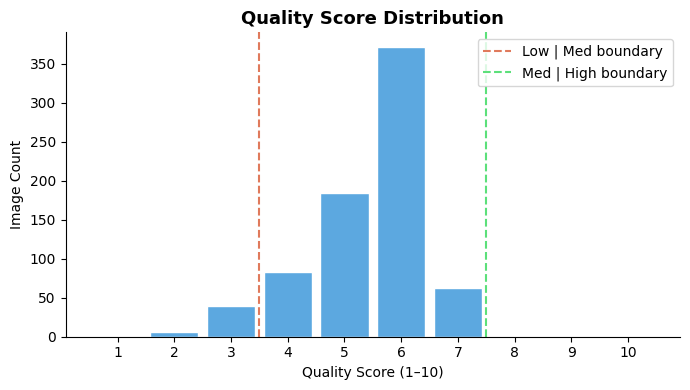


── Quality Bands ─────────────────────────────────────────
  Low  (1–3)  :    6 images  (0.8%)
  Med  (4–7)  :  640 images  (85.7%)
  High (8–10) :    0 images  (0.0%)

── Split Summary ─────────────────────────────────────────
Split     Patients   Images    GON+    GON-  Imbalance
------------------------------------------------------
Train          201      513     370     143      2.59x
Val             43      118      93      25      3.72x
Test            44      116      85      31      2.74x


── Class Distribution (Train Split) ──────────────────
  GON+  :  370  (72.1%)
  GON-  :  143  (27.9%)
  Total : 513


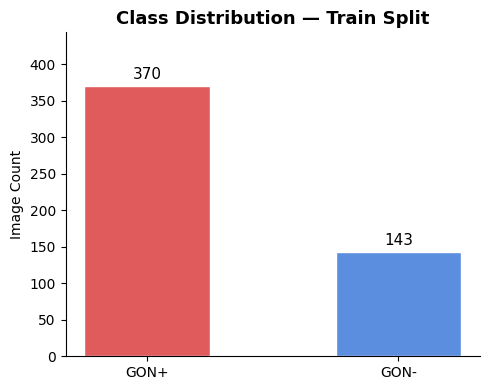


── Class Distribution (Val Split) ──────────────────
  GON+  :   93  (78.8%)
  GON-  :   25  (21.2%)
  Total : 118


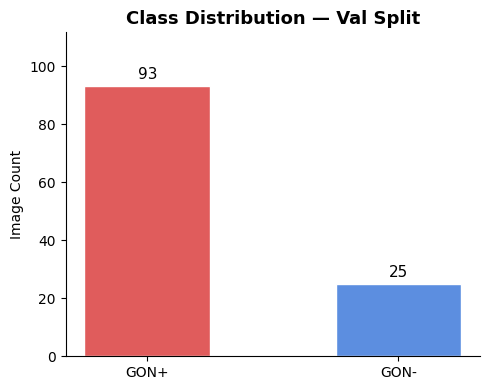


── Class Distribution (Test Split) ──────────────────
  GON+  :   85  (73.3%)
  GON-  :   31  (26.7%)
  Total : 116


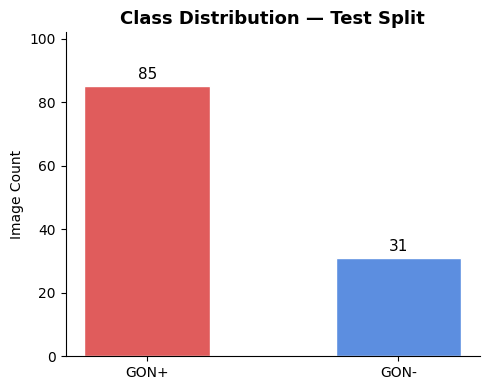

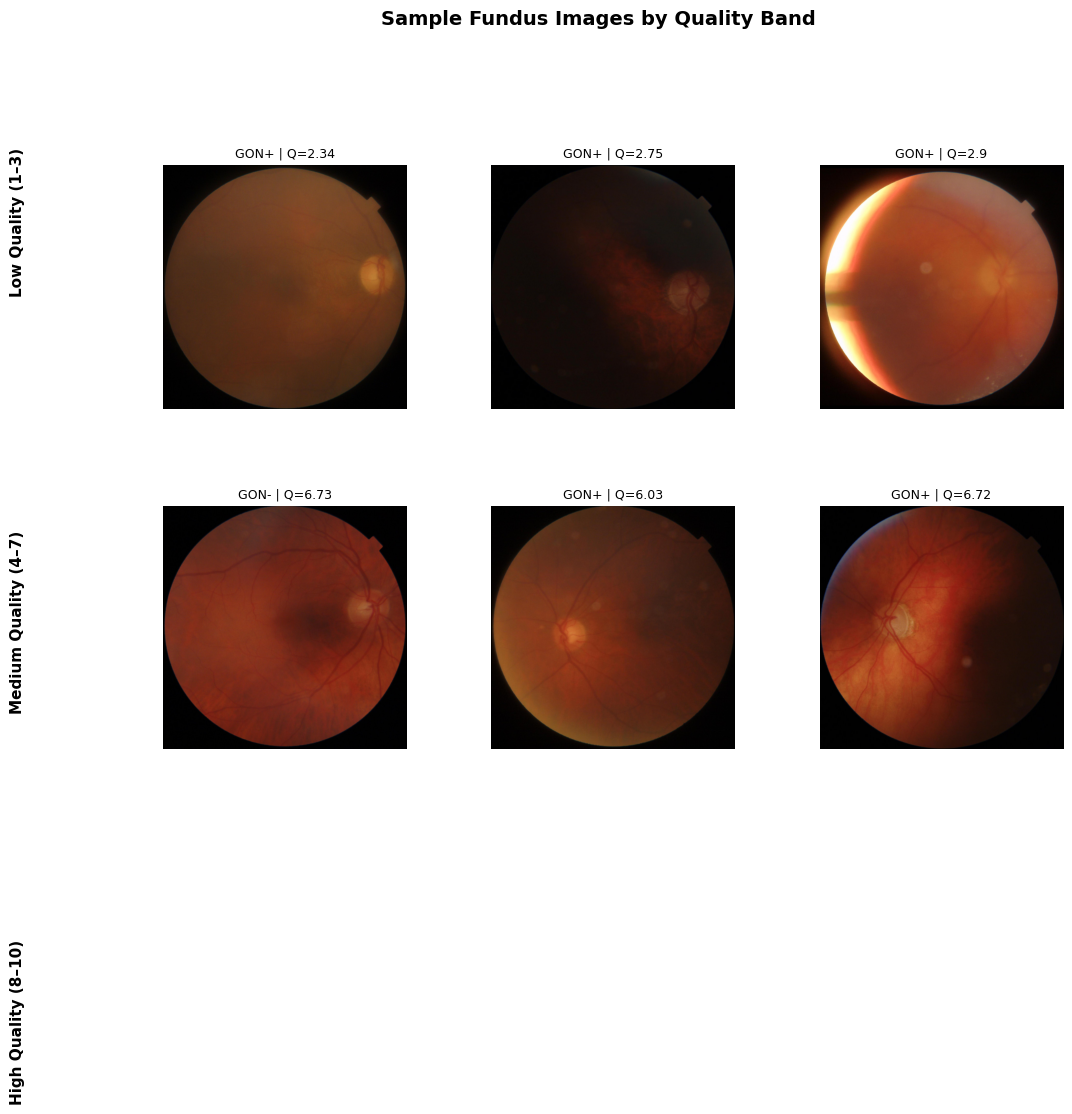


═══════════════════════════════════════════════════════
  Model : GlaucomaBaseCNN    (Baseline)
  Trainable parameters : 3,346,274
  Size (FP32)          : 12.77 MB
═══════════════════════════════════════════════════════

═══════════════════════════════════════════════════════
  Model : GlaucomaQualityCNN (Quality-Aware)
  Trainable parameters : 3,355,058
  Size (FP32)          : 12.80 MB
═══════════════════════════════════════════════════════


In [17]:
# =============================================================================
# EXECUTION 1 — INISIALISASI + EDA
# =============================================================================

cfg = Config()
df = load_and_validate_labels(cfg)
train_df, val_df, test_df = patient_level_split(df, cfg)
verify_no_leakage(train_df, val_df, test_df)
class_weights = compute_class_weights_for_loss(train_df)

loaders_base    = build_dataloaders(train_df, val_df, test_df, cfg,
                                    return_quality=False)
loaders_quality = build_dataloaders(train_df, val_df, test_df, cfg,
                                    return_quality=True)

# ── EDA ───────────────────────────────────────────────────────
eda_class_distribution(df, title="Full Dataset")
eda_quality_distribution(df)
eda_split_summary(train_df, val_df, test_df)
eda_class_distribution(train_df, title="Train Split")
eda_class_distribution(val_df,   title="Val Split")
eda_class_distribution(test_df,  title="Test Split")
eda_sample_images(df, n_per_band=3)

# ── Model ─────────────────────────────────────────────────────
model_baseline = GlaucomaBaseCNN(num_classes=2, dropout_rate=0.4)
model_quality  = GlaucomaQualityCNN(num_classes=2, dropout_rate=0.4,
                                     quality_embed_dim=16)

print_model_summary(model_baseline, "GlaucomaBaseCNN    (Baseline)")
print_model_summary(model_quality,  "GlaucomaQualityCNN (Quality-Aware)")

# **TRAINING & EVALUATION**

In [18]:
# =============================================================================
#  1 — HYPERPARAMETER CONFIGURATION
# =============================================================================

class TrainConfig:
    """
    All hyperparameters in one place — easy to tweak and document for report.

    Justifications
    ──────────────
    LR = 1e-3         : Standard starting point for AdamW. CosineAnnealing
                        will decay this smoothly to 1e-5 by the final epoch.
    WEIGHT_DECAY=1e-4 : Mild L2 penalty — prevents memorisation on 747 images
                        without being so strong it prevents learning.
    EPOCHS = 60       : Sufficient for convergence; early stopping will halt
                        training earlier if val_loss plateaus.
    PATIENCE = 12     : ~20% of total epochs — gives the model room to escape
                        local plateaus before stopping.
    BATCH_SIZE = 32   : Balances gradient noise (too small) vs memory and BN
                        stability (too large). drop_last=True on train loader
                        prevents single-sample batches that break BatchNorm.
    THRESHOLD = 0.5   : Default decision threshold. Can be tuned post-training
                        via ROC curve to maximise Recall for clinical use.
    """

    # ── Optimiser ─────────────────────────────────────────────────────────────
    LR            = 1e-3
    WEIGHT_DECAY  = 1e-4
    EPOCHS        = 60
    PATIENCE      = 12       # early stopping patience

    # ── DataLoader ────────────────────────────────────────────────────────────
    BATCH_SIZE    = 32

    # ── Decision threshold (applied at evaluation time) ───────────────────────
    THRESHOLD     = 0.5

    # ── Checkpoint filenames ──────────────────────────────────────────────────
    CKPT_BASELINE = "best_baseline_cnn.pt"
    CKPT_QUALITY  = "best_quality_cnn.pt"


In [19]:
# =============================================================================
#  2 — TRAINING LOOP
# =============================================================================

class EarlyStopping:
    """
    Monitor validation loss and stop training when it stops improving.

    Saves the best model state dict to disk automatically so we can always
    restore the best checkpoint even if the final epoch overfit.
    """

    def __init__(self, patience: int = 12, delta: float = 1e-4,
                 checkpoint_path: str = "best_model.pt"):
        self.patience         = patience
        self.delta            = delta
        self.checkpoint_path  = checkpoint_path
        self.counter          = 0
        self.best_loss        = np.inf
        self.best_state       = None
        self.triggered        = False

    def step(self, val_loss: float, model: nn.Module) -> bool:
        if val_loss < self.best_loss - self.delta:
            self.best_loss  = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            torch.save(self.best_state, self.checkpoint_path)
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.triggered = True
        return self.triggered

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)
            print(f"    ✅ Best weights restored  (best val_loss = {self.best_loss:.4f})")


# ─────────────────────────────────────────────────────────────────────────────

def _run_one_epoch(
    model:            nn.Module,
    loader:           DataLoader,
    criterion:        nn.Module,
    optimizer:        optim.Optimizer,
    scaler:           GradScaler,
    device:           torch.device,
    is_quality_model: bool,
    training:         bool,
) -> tuple[float, float]:
    """
    Generic single-epoch forward (+ optional backward) pass.

    Handles both model types:
      • Baseline      → batch = (images, labels)
      • Quality-Aware → batch = (images, labels, quality_scores)

    Mixed-precision (autocast) is used for both training and evaluation
    to keep memory usage consistent.

    Gradient clipping (max_norm=1.0) prevents exploding gradients —
    especially important in early epochs when weights are random.
    """
    model.train() if training else model.eval()
    total_loss, correct, n = 0.0, 0, 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in loader:
            images = batch[0].to(device)
            labels = batch[1].to(device)

            with autocast():
                if is_quality_model:
                    quality = batch[2].to(device)
                    logits  = model(images, quality)
                else:
                    logits  = model(images)
                loss = criterion(logits, labels)

            if training:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item() * images.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            n          += images.size(0)

    return total_loss / n, correct / n


# ─────────────────────────────────────────────────────────────────────────────

def train_model(
    model:            nn.Module,
    loaders:          dict,
    class_weights:    torch.Tensor,
    device:           torch.device,
    model_name:       str  = "model",
    is_quality_model: bool = False,
    cfg:              TrainConfig = None,
) -> dict:
    """
    Full training orchestrator.

    Training choices justified:
    ───────────────────────────
    • Loss  : CrossEntropyLoss with class_weights → handles GON+ / GON-
              imbalance (~2.75 : 1) without discarding any images.
    • Optim : AdamW (Adam + decoupled weight decay). Outperforms plain Adam
              on small medical datasets due to better regularisation.
    • Sched : CosineAnnealingLR — smooth LR decay, no manual milestones.
    • AMP   : Mixed FP16/FP32 precision via GradScaler → ~2× faster on GPU.

    Returns
    -------
    history : dict with keys train_loss, val_loss, train_acc, val_acc, lr
    """
    if cfg is None:
        cfg = TrainConfig()

    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

    optimizer = optim.AdamW(
        model.parameters(),
        lr           = cfg.LR,
        weight_decay = cfg.WEIGHT_DECAY,
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cfg.EPOCHS, eta_min=cfg.LR * 0.01
    )
    scaler     = GradScaler()
    stopper    = EarlyStopping(
        patience        = cfg.PATIENCE,
        checkpoint_path = cfg.CKPT_BASELINE if not is_quality_model
                          else cfg.CKPT_QUALITY,
    )

    history = {k: [] for k in
               ["train_loss", "val_loss", "train_acc", "val_acc", "lr"]}

    # ── Header ────────────────────────────────────────────────────────────────
    print(f"\n{'═'*68}")
    print(f"  TRAINING  →  {model_name}")
    print(f"  LR={cfg.LR}  |  WD={cfg.WEIGHT_DECAY}  |  "
          f"Epochs={cfg.EPOCHS}  |  Patience={cfg.PATIENCE}  |  BS={cfg.BATCH_SIZE}")
    print(f"{'═'*68}")
    print(f"  {'Ep':>4}  {'TrLoss':>8}  {'VlLoss':>8}  "
          f"{'TrAcc':>7}  {'VlAcc':>7}  {'LR':>9}  {'':>5}")
    print(f"  {'─'*60}")

    best_val_loss = np.inf

    for epoch in range(1, cfg.EPOCHS + 1):
        t0 = time.time()

        tr_loss, tr_acc = _run_one_epoch(
            model, loaders["train"], criterion, optimizer,
            scaler, device, is_quality_model, training=True,
        )
        vl_loss, vl_acc = _run_one_epoch(
            model, loaders["val"], criterion, optimizer,
            scaler, device, is_quality_model, training=False,
        )

        scheduler.step()
        lr_now = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(tr_loss)
        history["val_loss"]  .append(vl_loss)
        history["train_acc"] .append(tr_acc)
        history["val_acc"]   .append(vl_acc)
        history["lr"]        .append(lr_now)

        # Mark best epoch
        marker = " ◀ best" if vl_loss < best_val_loss else ""
        if vl_loss < best_val_loss:
            best_val_loss = vl_loss

        elapsed = time.time() - t0
        print(f"  {epoch:4d}  {tr_loss:8.4f}  {vl_loss:8.4f}  "
              f"{tr_acc:7.4f}  {vl_acc:7.4f}  {lr_now:9.2e}  "
              f"({elapsed:.1f}s){marker}")

        if stopper.step(vl_loss, model):
            print(f"\n  ⏹  Early stopping triggered at epoch {epoch}")
            break

    stopper.restore_best(model)
    history["best_val_loss"] = stopper.best_loss
    history["stopped_epoch"] = epoch
    return history



In [20]:
# =============================================================================
#  3 — COMPREHENSIVE MEDICAL EVALUATION (7 METRICS)
# =============================================================================

@torch.no_grad()
def collect_predictions(
    model:            nn.Module,
    loader:           DataLoader,
    device:           torch.device,
    is_quality_model: bool = False,
    threshold:        float = 0.5,
) -> dict:
    """
    Run model over the full loader and collect:
      • true labels
      • predicted class (hard decision via threshold)
      • predicted probability P(GON+)
      • image paths (for error analysis)
      • quality scores (if available)

    Using a configurable threshold rather than hardcoded 0.5 allows
    post-hoc threshold tuning — important in glaucoma screening where
    missing a positive (FN) is more dangerous than a false alarm (FP).
    """
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    all_paths, all_quality           = [], []

    for batch in loader:
        images = batch[0].to(device)
        labels = batch[1].to(device)

        with autocast():
            if is_quality_model:
                quality = batch[2].to(device)
                logits  = model(images, quality)
                all_quality.extend(quality.cpu().numpy().tolist())
            else:
                logits = model(images)

        probs = F.softmax(logits, dim=1)[:, 1]          # P(GON+)
        preds = (probs >= threshold).long()

        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds .extend(preds .cpu().numpy().tolist())
        all_probs .extend(probs .cpu().numpy().tolist())

    return {
        "labels"  : np.array(all_labels),
        "preds"   : np.array(all_preds),
        "probs"   : np.array(all_probs),
        "quality" : np.array(all_quality) if all_quality else None,
    }


def compute_all_metrics(results: dict, model_name: str = "") -> dict:
    """
    Compute all 7 required medical AI metrics from collected predictions.

    Clinical notes embedded in variable names:
    ───────────────────────────────────────────
    Recall / Sensitivity = TP / (TP + FN)
      → The most critical metric for glaucoma screening.
        A missed glaucoma case (FN) can lead to irreversible vision loss.
        We want this as HIGH as possible, even at the cost of Precision.

    Specificity = TN / (TN + FP)
      → False alarms (FP) send healthy patients for unnecessary follow-up.
        Important to balance against Sensitivity.

    ROC-AUC
      → Threshold-independent measure. Reports how well the model RANKS
        positive over negative samples. A random classifier scores 0.5.
    """
    labels = results["labels"]
    preds  = results["preds"]
    probs  = results["probs"]

    cm             = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()
    specificity    = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    metrics = {
        "model"       : model_name,
        # ── Core 7 metrics ───────────────────────────────────────────────────
        "accuracy"    : accuracy_score (labels, preds),
        "precision"   : precision_score(labels, preds, zero_division=0),
        "recall"      : recall_score   (labels, preds, zero_division=0),  # Sensitivity
        "specificity" : specificity,
        "f1"          : f1_score       (labels, preds, zero_division=0),
        "roc_auc"     : roc_auc_score  (labels, probs),
        # ── Confusion matrix components ───────────────────────────────────────
        "tp": int(tp), "tn": int(tn),
        "fp": int(fp), "fn": int(fn),
        "confusion_matrix": cm,
    }
    return metrics


def print_metrics(metrics: dict) -> None:
    """Pretty-print all 7 metrics for a single model."""
    print(f"\n{'═'*52}")
    print(f"  EVALUATION RESULTS — {metrics['model']}")
    print(f"{'═'*52}")

    rows = [
        ("Accuracy",         metrics["accuracy"],    ""),
        ("Precision",        metrics["precision"],   ""),
        ("Recall/Sensitivity",metrics["recall"],     " ← KEY for screening"),
        ("Specificity",      metrics["specificity"], ""),
        ("F1-Score",         metrics["f1"],          ""),
        ("ROC-AUC",          metrics["roc_auc"],     ""),
    ]
    for name, val, note in rows:
        bar  = "█" * int(val * 24)
        pct  = f"{val*100:5.1f}%"
        print(f"  {name:<22} {pct}  {bar}{note}")

    print(f"\n  Confusion Matrix:")
    print(f"  ┌─────────────────┬──────────────┬──────────────┐")
    print(f"  │                 │  Pred GON+   │  Pred GON-   │")
    print(f"  ├─────────────────┼──────────────┼──────────────┤")
    print(f"  │  True GON+      │  TP = {metrics['tp']:5d}   │  FN = {metrics['fn']:5d}   │")
    print(f"  │  True GON-      │  FP = {metrics['fp']:5d}   │  TN = {metrics['tn']:5d}   │")
    print(f"  └─────────────────┴──────────────┴──────────────┘")
    print(f"{'═'*52}")



In [21]:
# =============================================================================
#  4 — COMPARATIVE RESULTS TABLE
# =============================================================================

def print_comparison_table(m1: dict, m2: dict) -> pd.DataFrame:
    """
    Print a side-by-side comparison of Baseline vs Quality-Aware CNN.
    Returns a DataFrame for easy export to CSV / LaTeX for the report.
    """
    metric_keys    = ["accuracy","precision","recall","specificity","f1","roc_auc"]
    metric_labels  = ["Accuracy","Precision","Recall/Sensitivity",
                      "Specificity","F1-Score","ROC-AUC"]

    rows = []
    print(f"\n{'═'*72}")
    print(f"  COMPARATIVE RESULTS — Baseline CNN  vs  Quality-Aware CNN")
    print(f"{'═'*72}")
    print(f"  {'Metric':<22}  {'Baseline':>10}  {'Quality-Aware':>14}  "
          f"{'Δ':>8}  {'Winner':>12}")
    print(f"  {'─'*66}")

    for key, label in zip(metric_keys, metric_labels):
        b     = m1[key]
        q     = m2[key]
        delta = q - b
        sign  = "▲" if delta > 0 else ("▼" if delta < 0 else "─")
        winner = m2["model"] if delta > 0 else (m1["model"] if delta < 0 else "Tie")
        print(f"  {label:<22}  {b:10.4f}  {q:14.4f}  "
              f"  {sign}{abs(delta):.4f}  {winner:>12}")
        rows.append({
            "Metric"       : label,
            m1["model"]    : round(b, 4),
            m2["model"]    : round(q, 4),
            "Delta"        : round(delta, 4),
            "Winner"       : winner,
        })

    # ── Confusion matrix side-by-side ─────────────────────────────────────────
    print(f"\n  {'':22}  {'Baseline':>24}  {'Quality-Aware':>24}")
    print(f"  {'─'*66}")
    for stat in [("TP","tp"),("TN","tn"),("FP","fp"),("FN","fn")]:
        label, key = stat
        print(f"  {label:<22}  {m1[key]:>24d}  {m2[key]:>24d}")
    print(f"{'═'*72}")

    df = pd.DataFrame(rows)
    df.to_csv("comparison_table.csv", index=False)
    print("\n  📄  Saved to comparison_table.csv")
    return df

In [22]:

# =============================================================================
#  5 — VISUALISATION & ERROR ANALYSIS
# =============================================================================

def plot_confusion_matrices(m1: dict, m2: dict) -> None:
    """Side-by-side heatmap confusion matrices for both models."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Confusion Matrices — Baseline vs Quality-Aware CNN",
                 fontsize=14, fontweight="bold")

    for ax, metrics in zip(axes, [m1, m2]):
        tn, fp = metrics["tn"], metrics["fp"]
        fn, tp = metrics["fn"], metrics["tp"]
        cm_arr = np.array([[tn, fp], [fn, tp]])

        sns.heatmap(
            cm_arr, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Pred GON-", "Pred GON+"],
            yticklabels=["True GON-", "True GON+"],
            annot_kws={"size": 14, "weight": "bold"},
        )
        ax.set_title(metrics["model"], fontsize=12, fontweight="bold")
        ax.set_ylabel("Actual Class")
        ax.set_xlabel("Predicted Class")

        # Annotate sensitivity and specificity in corner
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        ax.text(0.02, 0.02,
                f"Sensitivity={sens:.3f}\nSpecificity={spec:.3f}",
                transform=ax.transAxes, fontsize=9,
                verticalalignment="bottom",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow",
                          alpha=0.8))

    plt.tight_layout()
    plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  📊  Saved → confusion_matrices.png")


def plot_roc_curves(
    results_base: dict,
    results_qual: dict,
    m1_name: str,
    m2_name: str,
) -> None:
    """Overlay ROC curves for both models on one plot."""
    fig, ax = plt.subplots(figsize=(7, 6))

    for results, name, color in [
        (results_base, m1_name, "#5c8ee0"),
        (results_qual, m2_name, "#e05c5c"),
    ]:
        fpr, tpr, _ = roc_curve(results["labels"], results["probs"])
        auc         = roc_auc_score(results["labels"], results["probs"])
        ax.plot(fpr, tpr, color=color, linewidth=2.5,
                label=f"{name}  (AUC = {auc:.3f})")

    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC = 0.500)")
    ax.fill_between([0,1],[0,1], alpha=0.05, color="grey")

    ax.set_title("ROC Curves — Baseline vs Quality-Aware CNN",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("False Positive Rate  (1 − Specificity)")
    ax.set_ylabel("True Positive Rate  (Sensitivity / Recall)")
    ax.legend(loc="lower right", fontsize=10)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig("roc_curves.png", dpi=150)
    plt.show()
    print("  📊  Saved → roc_curves.png")


def plot_training_curves(history1: dict, history2: dict,
                          name1: str, name2: str) -> None:
    """2×2 grid: loss and accuracy curves for both models."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle("Training Curves — Baseline vs Quality-Aware CNN",
                 fontsize=14, fontweight="bold")

    plot_cfg = [
        (0, "train_loss", "val_loss",  "Loss",     True),
        (1, "train_acc",  "val_acc",   "Accuracy", False),
    ]

    for row, (hist, name) in enumerate([(history1, name1), (history2, name2)]):
        for col, tr_key, vl_key, ylabel, add_stopped in plot_cfg:
            ax  = axes[row][col]
            eps = range(1, len(hist[tr_key]) + 1)
            ax.plot(eps, hist[tr_key], color="#5c8ee0", lw=2,   label="Train")
            ax.plot(eps, hist[vl_key], color="#e05c5c", lw=2,
                    linestyle="--", label="Validation")

            # Mark early stopping epoch
            if add_stopped and "stopped_epoch" in hist:
                ax.axvline(hist["stopped_epoch"], color="grey",
                           linestyle=":", lw=1.5, label="Early stop")

            ax.set_title(f"{name} — {ylabel}", fontsize=11)
            ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
            ax.legend(fontsize=9); sns.despine(ax=ax)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()
    print("  📊  Saved → training_curves.png")


# ─────────────────────────────────────────────────────────────────────────────
# ERROR ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────

@torch.no_grad()
def collect_predictions_with_paths(
    model:            nn.Module,
    test_df:          pd.DataFrame,
    device:           torch.device,
    cfg:              "Config",
    is_quality_model: bool = False,
    threshold:        float = 0.5,
) -> pd.DataFrame:
    """
    Run inference sample-by-sample on the test set and attach predictions
    back to the test DataFrame.

    Returns a DataFrame with extra columns:
      pred_label, pred_prob, error_type
        where error_type ∈ {TP, TN, FP, FN, None}

    We iterate sample-by-sample here (not batch) so we retain exact
    row-level alignment with test_df without worrying about drop_last.
    """
    from torchvision import transforms as T

    tfm = T.Compose([
        T.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)),
        T.CenterCrop(cfg.IMAGE_SIZE),
        T.ToTensor(),
        T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])

    model.eval()
    pred_labels, pred_probs = [], []

    for _, row in test_df.iterrows():
        try:
            img = Image.open(row["image_path"]).convert("RGB")
        except Exception:
            pred_labels.append(-1); pred_probs.append(-1.0)
            continue

        x = tfm(img).unsqueeze(0).to(device)   # (1, 3, 224, 224)

        with autocast():
            if is_quality_model:
                q      = torch.tensor([row["quality_score"]],
                                       dtype=torch.float32).to(device)
                logits = model(x, q)
            else:
                logits = model(x)

        prob  = F.softmax(logits, dim=1)[0, 1].item()
        pred  = 1 if prob >= threshold else 0
        pred_labels.append(pred)
        pred_probs .append(prob)

    df = test_df.copy()
    df["pred_label"] = pred_labels
    df["pred_prob"]  = pred_probs

    def _error_type(row):
        t, p = int(row["label_enc"]), int(row["pred_label"])
        if   t == 1 and p == 1: return "TP"
        elif t == 0 and p == 0: return "TN"
        elif t == 0 and p == 1: return "FP"
        elif t == 1 and p == 0: return "FN"
        return "Unknown"

    df["error_type"] = df.apply(_error_type, axis=1)
    return df


def plot_error_analysis(
    error_df:    pd.DataFrame,
    model_name:  str  = "Model",
    n_examples:  int  = 4,
) -> None:
    """
    Visualise False Positives and False Negatives with their images,
    confidence scores, and quality scores.

    Clinical significance:
    ──────────────────────
    FN (False Negative) — model missed a GON+ patient.
      → In glaucoma screening, this is the MOST DANGEROUS error type.
         The patient receives no follow-up and may suffer vision loss.

    FP (False Positive) — healthy patient flagged as GON+.
      → Causes unnecessary anxiety, follow-up costs, and healthcare burden.
         Less dangerous than FN but still important to minimise.
    """
    fp_df = error_df[error_df["error_type"] == "FP"].head(n_examples)
    fn_df = error_df[error_df["error_type"] == "FN"].head(n_examples)

    n_cols   = n_examples
    n_rows   = 2   # row 0 = FP, row 1 = FN
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(4 * n_cols, 4.5 * n_rows))
    fig.suptitle(f"Error Analysis — {model_name}\n"
                 f"Top row: False Positives (FP)  |  "
                 f"Bottom row: False Negatives (FN)",
                 fontsize=13, fontweight="bold")

    # Colour coding
    border_colors = {"FP": "#e05c5c", "FN": "#e0a05c"}
    label_text    = {
        "FP": "FALSE POSITIVE\n(Healthy → Predicted GON+)",
        "FN": "FALSE NEGATIVE\n(GON+ → Predicted GON-)",
    }

    for row_idx, (error_kind, subset) in enumerate([("FP", fp_df),
                                                     ("FN", fn_df)]):
        for col_idx in range(n_cols):
            ax = axes[row_idx][col_idx]

            if col_idx < len(subset):
                rec = subset.iloc[col_idx]
                try:
                    img = Image.open(rec["image_path"]).convert("RGB")
                    ax.imshow(img)
                except Exception:
                    ax.set_facecolor("#222233")
                    ax.text(0.5, 0.5, "Image\nnot found",
                            ha="center", va="center",
                            transform=ax.transAxes, color="white")

                # Colour border to highlight error type
                for spine in ax.spines.values():
                    spine.set_edgecolor(border_colors[error_kind])
                    spine.set_linewidth(4)

                q_str = f"  Q={rec['quality_score']}" \
                        if "quality_score" in rec else ""
                ax.set_title(
                    f"{label_text[error_kind]}\n"
                    f"True: {rec['label']}  "
                    f"Conf: {rec['pred_prob']:.2f}{q_str}",
                    fontsize=8, color=border_colors[error_kind],
                    fontweight="bold",
                )
            else:
                ax.set_visible(False)

            ax.axis("off")

    plt.tight_layout()
    fname = f"error_analysis_{model_name.replace(' ','_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  📊  Saved → {fname}")


def print_error_summary(error_df: pd.DataFrame, model_name: str) -> None:
    """Print counts and quality-score breakdown of each error type."""
    counts = error_df["error_type"].value_counts()
    total  = len(error_df)

    print(f"\n── Error Summary — {model_name} ─────────────────────────")
    for etype in ["TP", "TN", "FP", "FN"]:
        cnt = counts.get(etype, 0)
        pct = cnt / total * 100
        bar = "█" * cnt
        print(f"  {etype}  {cnt:4d}  ({pct:5.1f}%)  {bar}")

    # Quality score breakdown for errors
    if "quality_score" in error_df.columns:
        print(f"\n── Mean Quality Score by Outcome ─────────────────────")
        for etype in ["TP", "TN", "FP", "FN"]:
            sub = error_df[error_df["error_type"] == etype]
            if len(sub) > 0:
                mq = sub["quality_score"].mean()
                print(f"  {etype}  mean quality = {mq:.2f}")
    print()



In [23]:
# =============================================================================
#  6 — MAIN ORCHESTRATOR
# =============================================================================

def run_full_pipeline(
    model_baseline,
    model_quality,
    loaders_base:    dict,
    loaders_quality: dict,
    train_df:        pd.DataFrame,
    val_df:          pd.DataFrame,
    test_df:         pd.DataFrame,
    class_weights:   torch.Tensor,
    cfg_data,           # Config object from data pipeline
    device:          torch.device,
):
    """
    Runs the complete training + evaluation + error analysis pipeline.

    Call this from your Colab notebook after defining all models and loaders:

        results = run_full_pipeline(
            model_baseline = model_baseline,
            model_quality  = model_quality,
            loaders_base    = loaders_base,
            loaders_quality = loaders_quality,
            train_df = train_df,
            val_df   = val_df,
            test_df  = test_df,
            class_weights = class_weights,
            cfg_data = cfg,
            device   = DEVICE,
        )
    """
    train_cfg = TrainConfig()

    # ── STEP 1 : Train Baseline ───────────────────────────────────────────────
    history_base = train_model(
        model            = model_baseline,
        loaders          = loaders_base,
        class_weights    = class_weights,
        device           = device,
        model_name       = "Baseline CNN",
        is_quality_model = False,
        cfg              = train_cfg,
    )

    # ── STEP 2 : Train Quality-Aware ─────────────────────────────────────────
    history_qual = train_model(
        model            = model_quality,
        loaders          = loaders_quality,
        class_weights    = class_weights,
        device           = device,
        model_name       = "Quality-Aware CNN",
        is_quality_model = True,
        cfg              = train_cfg,
    )

    # ── STEP 3 : Collect test-set predictions ─────────────────────────────────
    print("\n🔍  Evaluating on held-out test set …")
    raw_base = collect_predictions(
        model_baseline, loaders_base["test"],
        device, is_quality_model=False, threshold=train_cfg.THRESHOLD,
    )
    raw_qual = collect_predictions(
        model_quality, loaders_quality["test"],
        device, is_quality_model=True,  threshold=train_cfg.THRESHOLD,
    )

    # ── STEP 4 : Compute all 7 metrics ────────────────────────────────────────
    metrics_base = compute_all_metrics(raw_base, model_name="Baseline CNN")
    metrics_qual = compute_all_metrics(raw_qual, model_name="Quality-Aware CNN")

    print_metrics(metrics_base)
    print_metrics(metrics_qual)

    # ── STEP 5 : Comparative table ────────────────────────────────────────────
    comparison_df = print_comparison_table(metrics_base, metrics_qual)

    # ── STEP 6 : Visualisations ───────────────────────────────────────────────
    plot_confusion_matrices(metrics_base, metrics_qual)
    plot_roc_curves(raw_base, raw_qual,
                    "Baseline CNN", "Quality-Aware CNN")
    plot_training_curves(history_base, history_qual,
                         "Baseline CNN", "Quality-Aware CNN")

    # ── STEP 7 : Error analysis ───────────────────────────────────────────────
    print("\n🔬  Running error analysis …")
    for model, name, is_q in [
        (model_baseline, "Baseline CNN",      False),
        (model_quality,  "Quality-Aware CNN", True),
    ]:
        err_df = collect_predictions_with_paths(
            model, test_df, device, cfg_data,
            is_quality_model=is_q,
            threshold=train_cfg.THRESHOLD,
        )
        print_error_summary(err_df, name)
        plot_error_analysis(err_df, model_name=name, n_examples=4)
        err_df.to_csv(
            f"error_analysis_{name.replace(' ','_')}.csv", index=False
        )
        print(f"  📄  Saved → error_analysis_{name.replace(' ','_')}.csv")

    print("\n✅  Full pipeline complete.")
    print("    Output files:")
    for f in ["confusion_matrices.png", "roc_curves.png",
              "training_curves.png",
              "error_analysis_Baseline_CNN.png",
              "error_analysis_Quality-Aware_CNN.png",
              "comparison_table.csv"]:
        print(f"    • {f}")

    return {
        "history_base"  : history_base,
        "history_qual"  : history_qual,
        "metrics_base"  : metrics_base,
        "metrics_qual"  : metrics_qual,
        "comparison_df" : comparison_df,
    }


════════════════════════════════════════════════════════════════════
  TRAINING  →  Baseline CNN
  LR=0.001  |  WD=0.0001  |  Epochs=60  |  Patience=12  |  BS=32
════════════════════════════════════════════════════════════════════
    Ep    TrLoss    VlLoss    TrAcc    VlAcc         LR       
  ────────────────────────────────────────────────────────────
     1    0.9800    0.6578   0.5664   0.7797   9.99e-04  (24.9s) ◀ best
     2    0.6202    0.7112   0.6113   0.5339   9.97e-04  (23.9s)
     3    0.5319    0.9315   0.6660   0.5000   9.94e-04  (23.1s)
     4    0.4937    0.5990   0.6914   0.7712   9.89e-04  (24.1s) ◀ best
     5    0.4708    0.6512   0.6953   0.6949   9.83e-04  (24.1s)
     6    0.5320    0.7526   0.6680   0.6864   9.76e-04  (23.5s)
     7    0.4221    0.7012   0.7617   0.7119   9.67e-04  (23.8s)
     8    0.4533    0.8675   0.7598   0.7542   9.57e-04  (23.4s)
     9    0.3906    0.4255   0.7793   0.8051   9.46e-04  (22.4s) ◀ best
    10    0.3349    0.4153   0.8066 

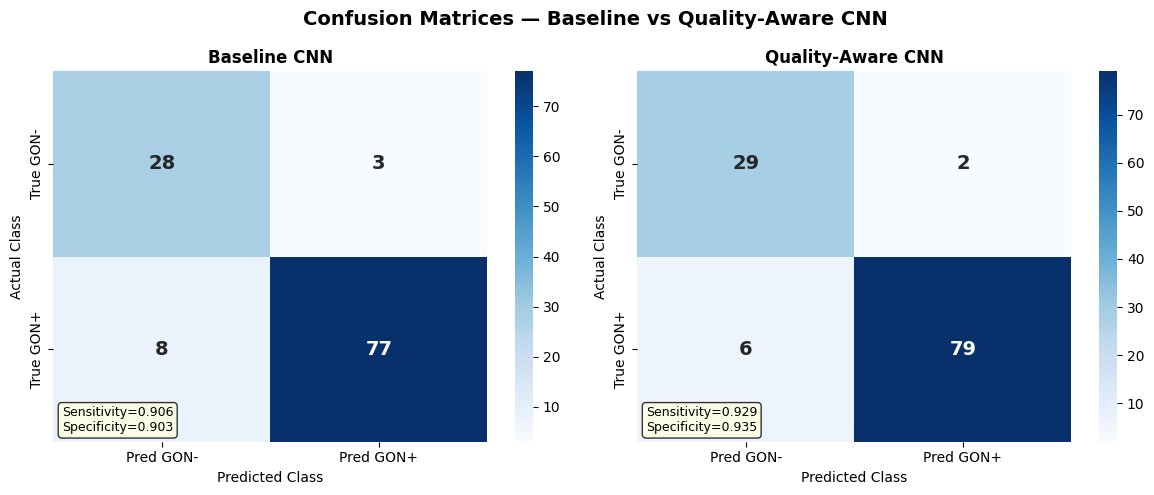

  📊  Saved → confusion_matrices.png


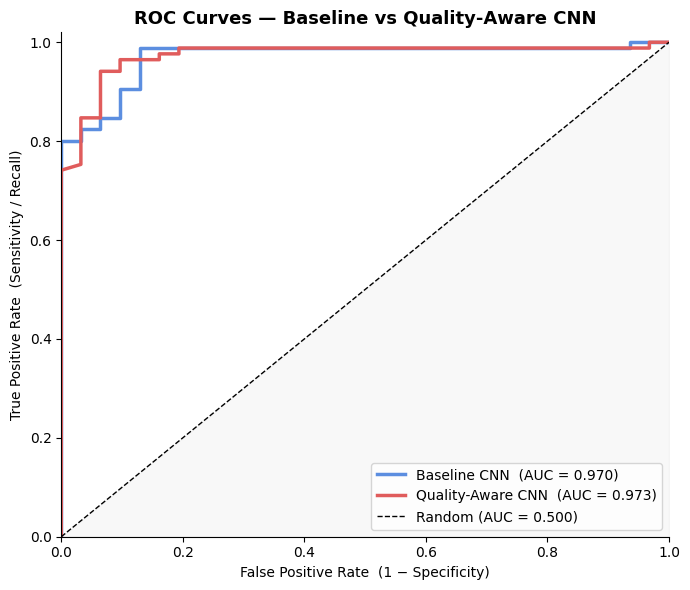

  📊  Saved → roc_curves.png


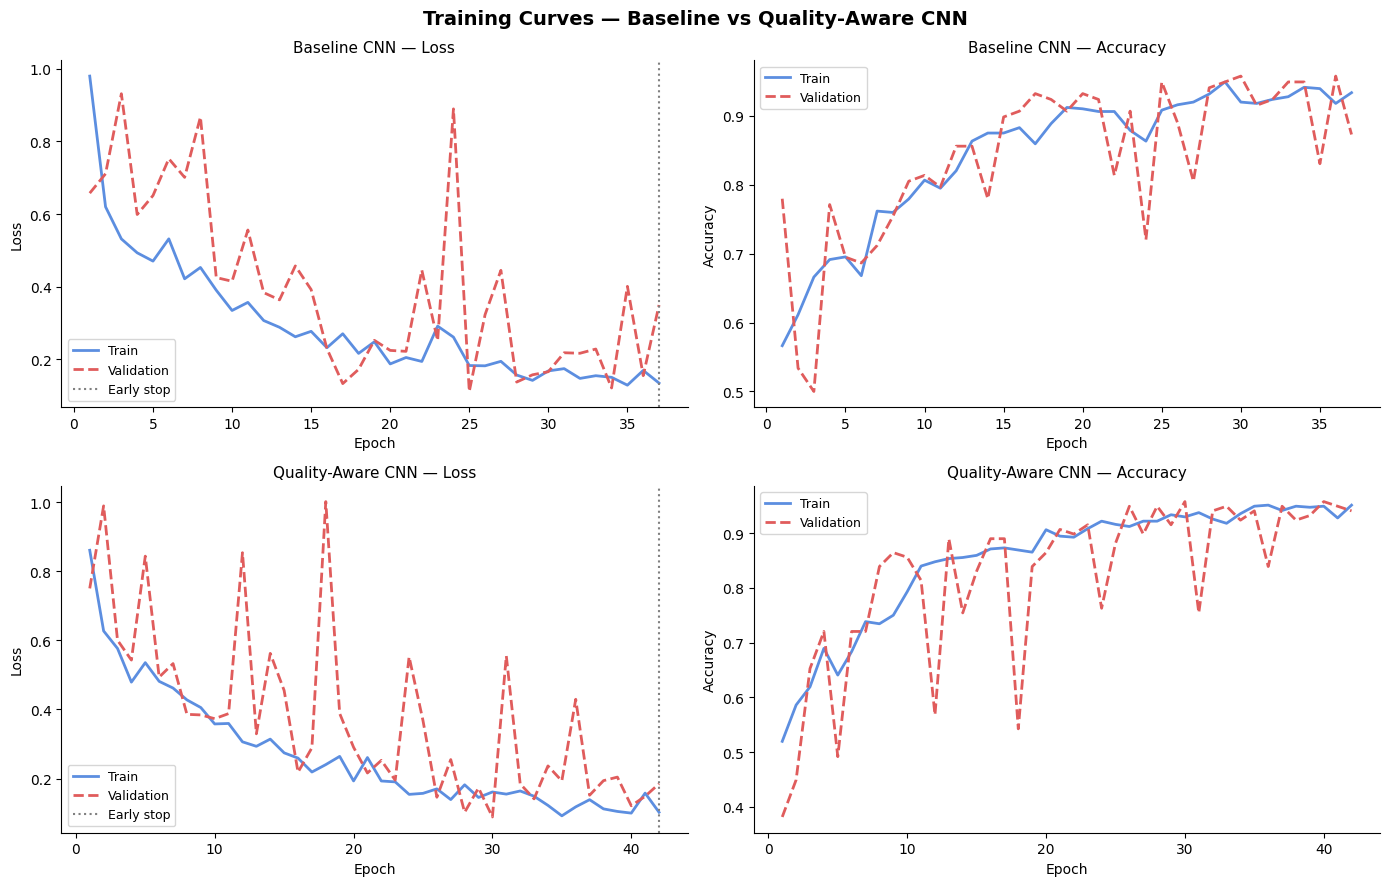

  📊  Saved → training_curves.png

🔬  Running error analysis …

── Error Summary — Baseline CNN ─────────────────────────
  TP    77  ( 66.4%)  █████████████████████████████████████████████████████████████████████████████
  TN    28  ( 24.1%)  ████████████████████████████
  FP     3  (  2.6%)  ███
  FN     8  (  6.9%)  ████████

── Mean Quality Score by Outcome ─────────────────────
  TP  mean quality = 5.86
  TN  mean quality = 6.29
  FP  mean quality = 6.49
  FN  mean quality = 5.89



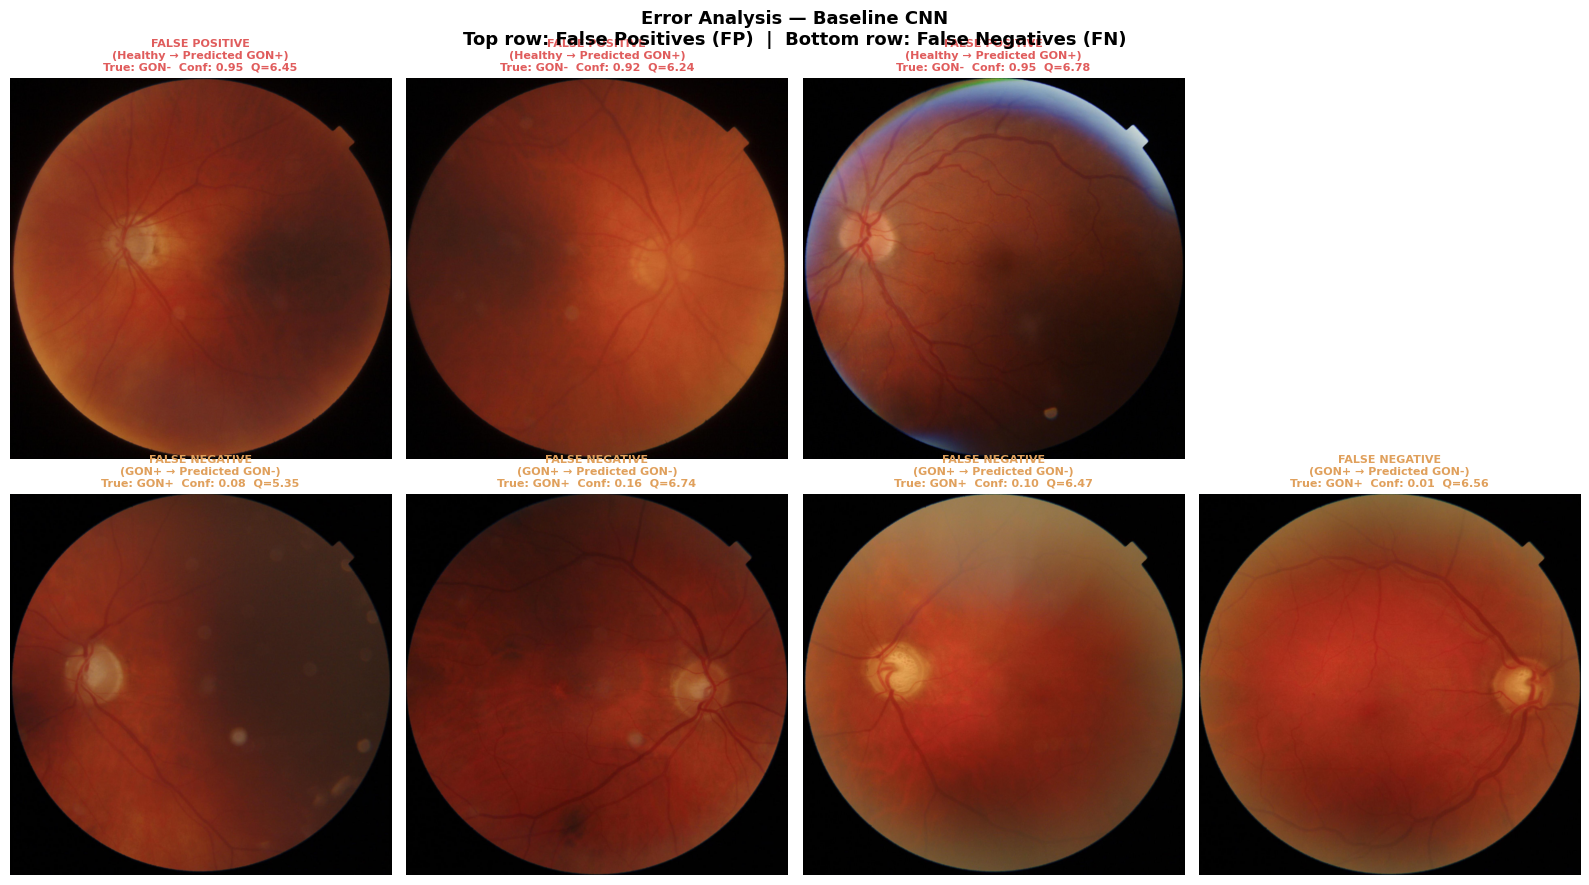

  📊  Saved → error_analysis_Baseline_CNN.png
  📄  Saved → error_analysis_Baseline_CNN.csv

── Error Summary — Quality-Aware CNN ─────────────────────────
  TP    79  ( 68.1%)  ███████████████████████████████████████████████████████████████████████████████
  TN    29  ( 25.0%)  █████████████████████████████
  FP     2  (  1.7%)  ██
  FN     6  (  5.2%)  ██████

── Mean Quality Score by Outcome ─────────────────────
  TP  mean quality = 5.83
  TN  mean quality = 6.31
  FP  mean quality = 6.35
  FN  mean quality = 6.20



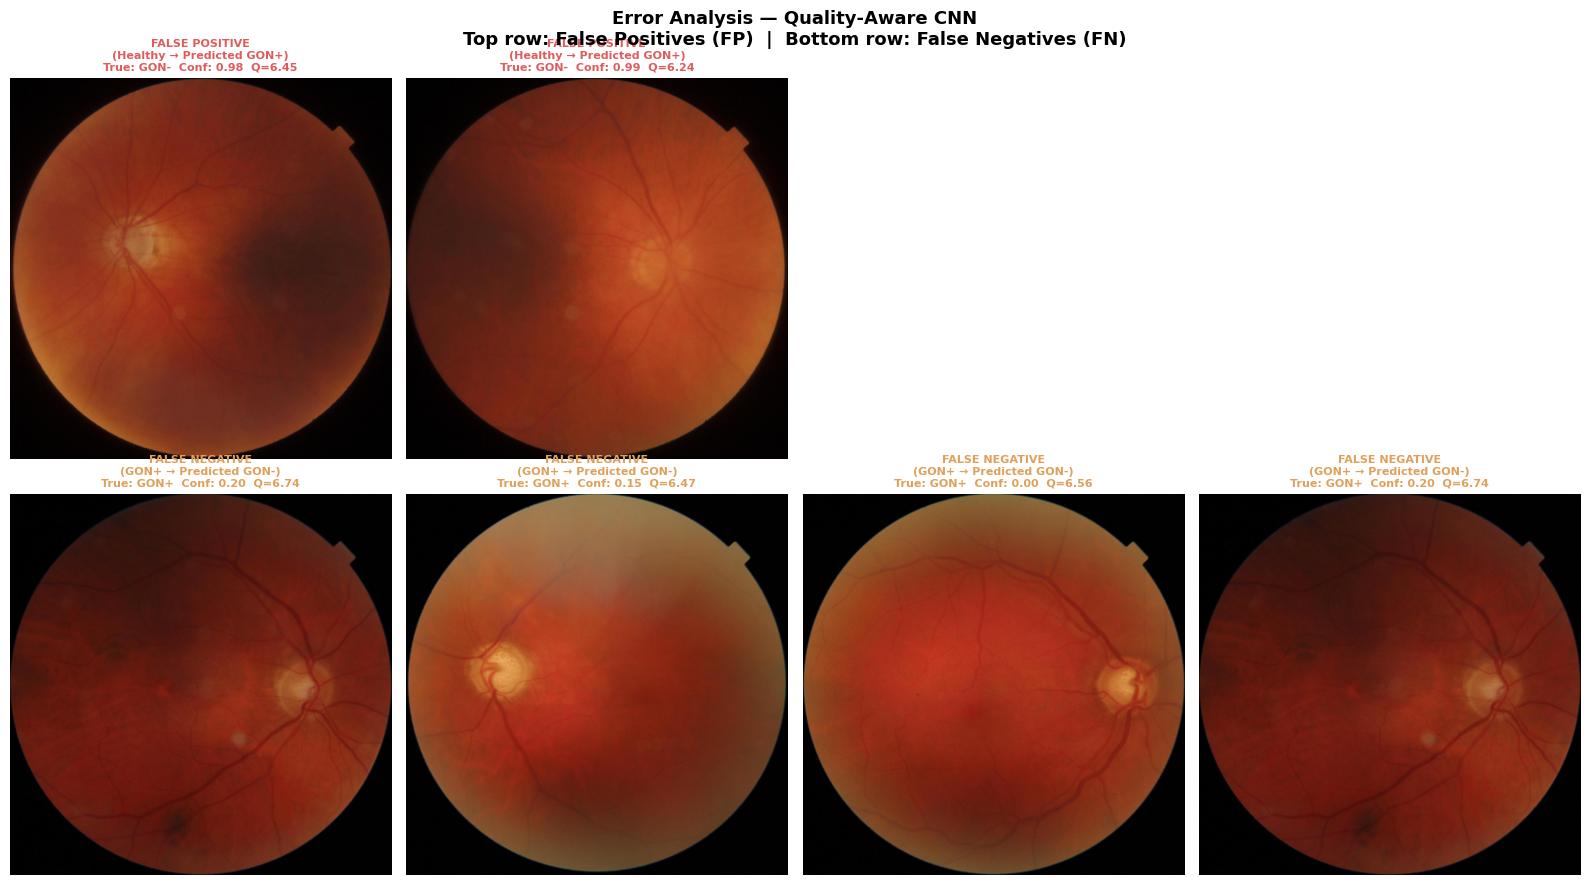

  📊  Saved → error_analysis_Quality-Aware_CNN.png
  📄  Saved → error_analysis_Quality-Aware_CNN.csv

✅  Full pipeline complete.
    Output files:
    • confusion_matrices.png
    • roc_curves.png
    • training_curves.png
    • error_analysis_Baseline_CNN.png
    • error_analysis_Quality-Aware_CNN.png
    • comparison_table.csv


In [24]:
results = run_full_pipeline(
    model_baseline  = model_baseline,
    model_quality   = model_quality,
    loaders_base    = loaders_base,
    loaders_quality = loaders_quality,
    train_df        = train_df,
    val_df          = val_df,
    test_df         = test_df,
    class_weights   = class_weights,
    cfg_data        = cfg,
    device          = DEVICE,
)